# 02. Portuguese fuel prices vs Brent
Weekly pump prices for gasoline and diesel in Portugal (EU Weekly Oil Bulletin), with and without taxes.

In [1]:
# Import the libraries
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Open the Oil Bulletin Excel file and list its sheets
file = "../data/raw/oil_bulletin_history.xlsx"
excel = pd.ExcelFile(file)
print(excel.sheet_names)

['Prices with taxes', 'Prices wo taxes', 'Consumption', 'VAT', 'Excise duties', 'Excise duties - components', 'Other Indirect Taxes']


In [3]:
# Print the column names about Portugal in each sheet
for sheet in excel.sheet_names:
    data = pd.read_excel(file, sheet_name=sheet)
    for col in data.columns:
        if "PT" in str(col):
            print(sheet, "->", col)

Prices with taxes -> PT_price_with_tax_euro95
Prices with taxes -> PT_price_with_tax_diesel
Prices with taxes -> PT_price_with_tax_heating_oil
Prices with taxes -> PT_price_with_tax_fuel_oil_1
Prices with taxes -> PT_price_with_tax_fuel_oil_2
Prices with taxes -> PT_price_with_tax_LPG
Prices wo taxes -> PT_price_wo_tax_euro95
Prices wo taxes -> PT_price_wo_tax_diesel
Prices wo taxes -> PT_price_wo_tax_heating_oil
Prices wo taxes -> PT_price_wo_tax_fuel_oil_1
Prices wo taxes -> PT_price_wo_tax_fuel_oil_2
Prices wo taxes -> PT_price_wo_tax_LPG
Consumption -> PT_consumption_euro95
Consumption -> PT_consumption_diesel
Consumption -> PT_consumption_hePTing_oil
Consumption -> PT_consumption_fuel_oil_1
Consumption -> PT_consumption_fuel_oil_2
Consumption -> PT_consumption_LPG


## Clean Portuguese prices (euros per litre, from 2019)

In [4]:
# Names of the sheets and columns in the Excel file (check them in the output above)
SHEET_WITH_TAX = "Prices with taxes"
SHEET_WITHOUT_TAX = "Prices wo taxes"

# Load prices with taxes and keep the date, gasoline and diesel for Portugal
with_tax = pd.read_excel(file, sheet_name=SHEET_WITH_TAX)
with_tax = with_tax.rename(columns={
    with_tax.columns[0]: "date",
    "PT_price_with_tax_euro95": "gasoline_with_tax",
    "PT_price_with_tax_diesel": "diesel_with_tax",
})
with_tax = with_tax[["date", "gasoline_with_tax", "diesel_with_tax"]]

# Load prices without taxes and do the same
without_tax = pd.read_excel(file, sheet_name=SHEET_WITHOUT_TAX)
without_tax = without_tax.rename(columns={
    without_tax.columns[0]: "date",
    "PT_price_wo_tax_euro95": "gasoline_without_tax",
    "PT_price_wo_tax_diesel": "diesel_without_tax",
})
without_tax = without_tax[["date", "gasoline_without_tax", "diesel_without_tax"]]

# Merge both tables by date
fuel = pd.merge(with_tax, without_tax, on="date")

# Turn dates into real dates and prices into numbers (in euros per 1000 litres)
fuel["date"] = pd.to_datetime(fuel["date"], errors="coerce", format="mixed")
price_columns = ["gasoline_with_tax", "diesel_with_tax", "gasoline_without_tax", "diesel_without_tax"]
for col in price_columns:
    fuel[col] = pd.to_numeric(fuel[col], errors="coerce")

# Remove empty rows, convert to euros per litre and keep data from 2019 onwards
fuel = fuel.dropna()
for col in price_columns:
    fuel[col] = fuel[col] / 1000
fuel = fuel[fuel["date"] >= "2019-01-01"]
fuel = fuel.sort_values("date")

# Save the clean data and check it
fuel.to_csv("../data/processed/fuel_prices_pt.csv", index=False)
print(len(fuel), "weeks")
fuel.tail()

395 weeks


,date,gasoline_with_tax,diesel_with_tax,gasoline_without_tax,diesel_without_tax
30,2026-08-31,2.013,2.029,1.031578,1.186283
29,2026-09-07,2.093,2.104,1.120478,1.272119
28,2026-09-14,2.072,2.152,1.093845,1.312233
27,2026-09-21,2.107,2.210,1.130600,1.370627
26,2026-09-28,2.099,2.186,1.123306,1.342585


## Pump prices vs Brent

In [5]:
# Load the weekly Brent data from notebook 01
brent = pd.read_csv("../data/processed/brent_eur_weekly.csv")
brent["date"] = pd.to_datetime(brent["date"])

# Move Brent dates from Sunday to the next Monday (pump prices on Monday reflect last week's oil price)
brent["date"] = brent["date"] + pd.Timedelta(days=1)

# Merge fuel prices and Brent by date
df = pd.merge(fuel, brent[["date", "brent_eur_litre"]], on="date")
print(len(df), "weeks with both fuel and Brent data")
df.tail()

395 weeks with both fuel and Brent data


,date,gasoline_with_tax,diesel_with_tax,gasoline_without_tax,diesel_without_tax,brent_eur_litre
390,2026-08-31,2.013,2.029,1.031578,1.186283,0.484528
391,2026-09-07,2.093,2.104,1.120478,1.272119,0.536991
392,2026-09-14,2.072,2.152,1.093845,1.312233,0.615192
393,2026-09-21,2.107,2.210,1.130600,1.370627,0.678115
394,2026-09-28,2.099,2.186,1.123306,1.342585,0.645257


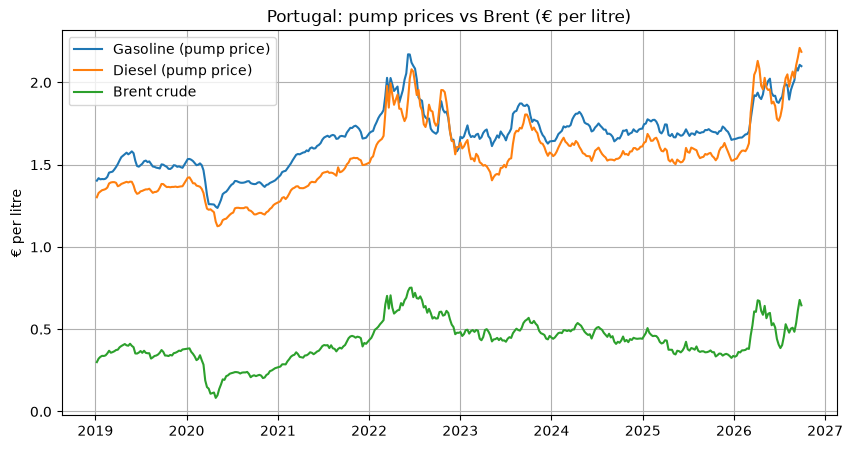

In [6]:
# Plot pump prices and Brent on the same chart
plt.figure(figsize=(10, 5))
plt.plot(df["date"], df["gasoline_with_tax"], label="Gasoline (pump price)")
plt.plot(df["date"], df["diesel_with_tax"], label="Diesel (pump price)")
plt.plot(df["date"], df["brent_eur_litre"], label="Brent crude")
plt.title("Portugal: pump prices vs Brent (€ per litre)")
plt.ylabel("€ per litre")
plt.legend()
plt.grid(True)

# Save and show the chart
plt.savefig("../figures/pump_prices_vs_brent.png")
plt.show()

## What makes up the price of a litre?
Pump price = oil cost (Brent) + margin (refining, logistics, biofuels, retail) + taxes (ISP + VAT)

In [7]:
# Taxes = price with taxes minus price without taxes
df["gasoline_taxes"] = df["gasoline_with_tax"] - df["gasoline_without_tax"]
df["diesel_taxes"] = df["diesel_with_tax"] - df["diesel_without_tax"]

# Margin = price without taxes minus the cost of crude oil
df["gasoline_margin"] = df["gasoline_without_tax"] - df["brent_eur_litre"]
df["diesel_margin"] = df["diesel_without_tax"] - df["brent_eur_litre"]

# Save the data and show the average of each part
df.to_csv("../data/processed/fuel_decomposition.csv", index=False)
df[["brent_eur_litre", "diesel_margin", "diesel_taxes", "diesel_with_tax"]].mean()

brent_eur_litre    0.424842
diesel_margin      0.367182
diesel_taxes       0.758684
diesel_with_tax    1.550709
dtype: float64

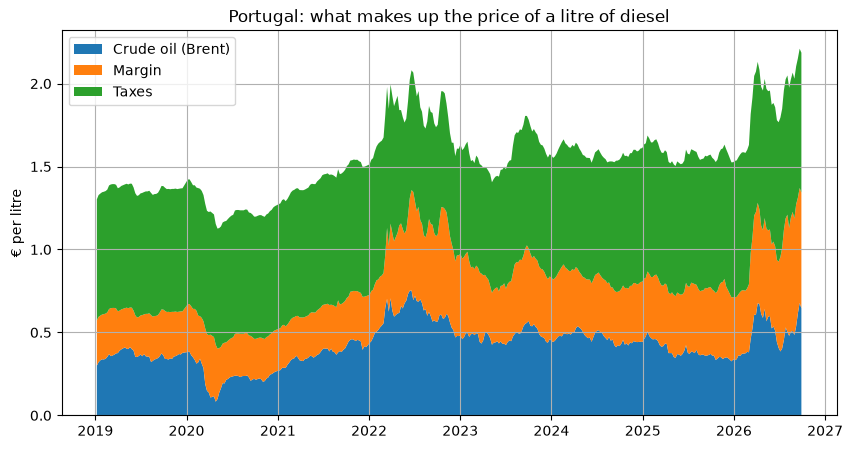

In [8]:
# Stacked chart of the diesel price: oil cost + margin + taxes
plt.figure(figsize=(10, 5))
plt.stackplot(
    df["date"],
    df["brent_eur_litre"], df["diesel_margin"], df["diesel_taxes"],
    labels=["Crude oil (Brent)", "Margin", "Taxes"],
)
plt.title("Portugal: what makes up the price of a litre of diesel")
plt.ylabel("€ per litre")
plt.legend(loc="upper left")
plt.grid(True)

# Save and show the chart
plt.savefig("../figures/diesel_price_decomposition.png")
plt.show()

## Rockets and feathers: do prices rise faster than they fall?
We use prices without taxes, so changes in tax policy don't affect the result.

In [9]:
# Import the regression library
import statsmodels.formula.api as smf

# Weekly change in Brent, split into rises and falls
df["d_brent"] = df["brent_eur_litre"].diff()
df["brent_up"] = df["d_brent"].clip(lower=0)
df["brent_down"] = df["d_brent"].clip(upper=0)

# The same changes one week earlier (prices can take more than a week to adjust)
df["brent_up_lag"] = df["brent_up"].shift(1)
df["brent_down_lag"] = df["brent_down"].shift(1)

# Weekly change in pump prices without taxes
df["d_gasoline"] = df["gasoline_without_tax"].diff()
df["d_diesel"] = df["diesel_without_tax"].diff()

In [10]:
# Run one regression per fuel and save the results
results = []

for fuel_name in ["gasoline", "diesel"]:
    formula = f"d_{fuel_name} ~ brent_up + brent_up_lag + brent_down + brent_down_lag"
    model = smf.ols(formula, data=df).fit()

    # Total pass-through after two weeks, for rises and for falls
    pass_up = model.params["brent_up"] + model.params["brent_up_lag"]
    pass_down = model.params["brent_down"] + model.params["brent_down_lag"]

    # Test if rises and falls are passed through equally
    test = model.f_test("brent_up + brent_up_lag = brent_down + brent_down_lag")

    results.append({
        "fuel": fuel_name,
        "pass_through_rises": round(pass_up, 2),
        "pass_through_falls": round(pass_down, 2),
        "p_value_difference": round(float(test.pvalue), 3),
    })

# Show the results as a table and save them
results = pd.DataFrame(results)
results.to_csv("../data/processed/rockets_feathers_results.csv", index=False)
results

,fuel,pass_through_rises,pass_through_falls,p_value_difference
0,gasoline,0.88,0.87,0.950
1,diesel,1.40,0.90,0.001


In [11]:
# Full regression output for diesel (to read the details)
model_diesel = smf.ols("d_diesel ~ brent_up + brent_up_lag + brent_down + brent_down_lag", data=df).fit()
print(model_diesel.summary())

                            OLS Regression Results                            
Dep. Variable:               d_diesel   R-squared:                       0.581
Model:                            OLS   Adj. R-squared:                  0.577
Method:                 Least Squares   F-statistic:                     134.5
Date:                Fri, 02 Oct 2026   Prob (F-statistic):           5.81e-72
Time:                        00:26:35   Log-Likelihood:                 967.98
No. Observations:                 393   AIC:                            -1926.
Df Residuals:                     388   BIC:                            -1906.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -0.0030      0.002     -1.

## Robustness check: HAC standard errors
Weekly price changes can be correlated over time, which makes normal standard errors too small.
HAC (Newey-West) standard errors correct for this.

In [12]:
# Run the same regressions again, now with HAC standard errors (4 weeks of lags)
robust_p_values = []

for fuel_name in ["gasoline", "diesel"]:
    formula = f"d_{fuel_name} ~ brent_up + brent_up_lag + brent_down + brent_down_lag"
    model = smf.ols(formula, data=df).fit(cov_type="HAC", cov_kwds={"maxlags": 4})
    test = model.f_test("brent_up + brent_up_lag = brent_down + brent_down_lag")
    robust_p_values.append(round(float(test.pvalue), 3))

# Add the robust p-values to the results table and save it again
results["p_value_difference_HAC"] = robust_p_values
results.to_csv("../data/processed/rockets_feathers_results.csv", index=False)
results

,fuel,pass_through_rises,pass_through_falls,p_value_difference,p_value_difference_HAC
0,gasoline,0.88,0.87,0.950,0.969
1,diesel,1.40,0.90,0.001,0.027


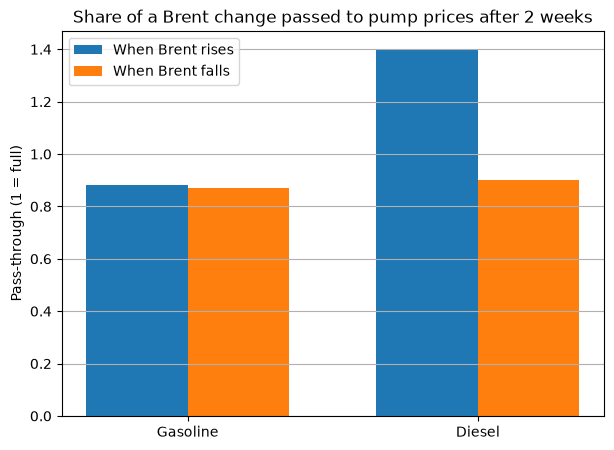

In [13]:
# Bar chart: how much of a Brent rise vs a Brent fall reaches the pump after two weeks
x = [0, 1]
width = 0.35

plt.figure(figsize=(7, 5))
plt.bar([i - width / 2 for i in x], results["pass_through_rises"], width, label="When Brent rises")
plt.bar([i + width / 2 for i in x], results["pass_through_falls"], width, label="When Brent falls")
plt.xticks(x, ["Gasoline", "Diesel"])
plt.title("Share of a Brent change passed to pump prices after 2 weeks")
plt.ylabel("Pass-through (1 = full)")
plt.legend()
plt.grid(True, axis="y")

# Save and show the chart
plt.savefig("../figures/rockets_feathers.png")
plt.show()

## Export for the Tableau dashboard

In [14]:
# Keep the columns needed for the dashboard and save them in one file
tableau_columns = [
    "date", "brent_eur_litre",
    "gasoline_with_tax", "gasoline_without_tax", "gasoline_taxes", "gasoline_margin",
    "diesel_with_tax", "diesel_without_tax", "diesel_taxes", "diesel_margin",
]
df[tableau_columns].to_csv("../data/processed/tableau_fuel_prices.csv", index=False)
print("Saved", len(df), "weeks for Tableau")

Saved 395 weeks for Tableau


In [15]:
# Share of taxes in the diesel price (average since 2019)
tax_share = df["diesel_taxes"].mean() / df["diesel_with_tax"].mean() * 100
print(round(tax_share), "% of the diesel price is taxes")

49 % of the diesel price is taxes


## Improved model: four weeks of adjustment and price momentum
Brent changes this week and in the previous three weeks, plus last week's pump price change. HAC standard errors.

In [16]:
# Brent rises and falls in the previous three weeks
for lag in [1, 2, 3]:
    df[f"brent_up_lag{lag}"] = df["brent_up"].shift(lag)
    df[f"brent_down_lag{lag}"] = df["brent_down"].shift(lag)

# Pump price change in the previous week (price momentum)
df["d_gasoline_lag1"] = df["d_gasoline"].shift(1)
df["d_diesel_lag1"] = df["d_diesel"].shift(1)

In [17]:
# Names of the Brent rise and fall terms
up_terms = ["brent_up", "brent_up_lag1", "brent_up_lag2", "brent_up_lag3"]
down_terms = ["brent_down", "brent_down_lag1", "brent_down_lag2", "brent_down_lag3"]

# Run the improved model for each fuel and save the long run pass-through
improved_results = []

for fuel_name in ["gasoline", "diesel"]:
    formula = f"d_{fuel_name} ~ brent_up + brent_up_lag1 + brent_up_lag2 + brent_up_lag3 + brent_down + brent_down_lag1 + brent_down_lag2 + brent_down_lag3 + d_{fuel_name}_lag1"
    model = smf.ols(formula, data=df).fit(cov_type="HAC", cov_kwds={"maxlags": 4})

    # Long run pass-through: sum of the Brent effects, adjusted for price momentum
    momentum = model.params[f"d_{fuel_name}_lag1"]
    long_run_up = model.params[up_terms].sum() / (1 - momentum)
    long_run_down = model.params[down_terms].sum() / (1 - momentum)

    # Test if rises and falls are passed through equally
    test = model.f_test("brent_up + brent_up_lag1 + brent_up_lag2 + brent_up_lag3 = brent_down + brent_down_lag1 + brent_down_lag2 + brent_down_lag3")

    improved_results.append({
        "fuel": fuel_name,
        "long_run_rises": round(long_run_up, 2),
        "long_run_falls": round(long_run_down, 2),
        "p_value_HAC": round(float(test.pvalue), 3),
    })

# Show and save the results
improved_results = pd.DataFrame(improved_results)
improved_results.to_csv("../data/processed/rockets_feathers_improved.csv", index=False)
improved_results

,fuel,long_run_rises,long_run_falls,p_value_HAC
0,gasoline,0.88,0.84,0.863
1,diesel,1.34,0.80,0.047


In [18]:
# Full regression tables of the improved model against Brent (HAC standard errors)
for fuel_name in ["gasoline", "diesel"]:
    formula = f"d_{fuel_name} ~ brent_up + brent_up_lag1 + brent_up_lag2 + brent_up_lag3 + brent_down + brent_down_lag1 + brent_down_lag2 + brent_down_lag3 + d_{fuel_name}_lag1"
    model = smf.ols(formula, data=df).fit(cov_type="HAC", cov_kwds={"maxlags": 4})
    test = model.f_test("brent_up + brent_up_lag1 + brent_up_lag2 + brent_up_lag3 = brent_down + brent_down_lag1 + brent_down_lag2 + brent_down_lag3")

    # Table with coefficients, HAC standard errors and p-values
    table = pd.DataFrame({
        "coefficient": model.params,
        "std_error_HAC": model.bse,
        "p_value": model.pvalues,
    }).round(3)
    table.to_csv(f"../data/processed/regression_brent_{fuel_name}.csv")

    # Show the table and the main statistics
    print(fuel_name.upper(), "| observations:", int(model.nobs), "| R-squared:", round(model.rsquared, 3), "| F test:", round(float(test.fvalue), 2), "| p-value:", round(float(test.pvalue), 3))
    print(table, "\n")

GASOLINE | observations: 391 | R-squared: 0.533 | F test: 0.03 | p-value: 0.863
                 coefficient  std_error_HAC  p_value
Intercept              0.000          0.001    0.699
brent_up               0.770          0.113    0.000
brent_up_lag1          0.001          0.116    0.994
brent_up_lag2         -0.142          0.111    0.201
brent_up_lag3          0.113          0.114    0.320
brent_down             0.665          0.091    0.000
brent_down_lag1        0.100          0.111    0.368
brent_down_lag2       -0.004          0.083    0.963
brent_down_lag3       -0.053          0.094    0.575
d_gasoline_lag1        0.159          0.074    0.032 

DIESEL | observations: 391 | R-squared: 0.6 | F test: 3.96 | p-value: 0.047
                 coefficient  std_error_HAC  p_value
Intercept             -0.003          0.001    0.067
brent_up               1.176          0.161    0.000
brent_up_lag1          0.058          0.172    0.737
brent_up_lag2         -0.232          0.108    